<a href="https://colab.research.google.com/github/odelia250900/Data-Science-HW2-ErrorAnalysis/blob/main/HW2_EDA_Odelia_Weizmann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
HW2: Regression and Classification: Error Analysis

**Methodology: Cross-Validation Setup & Choice of k**

For all analyses in this assignment, k-**fold cross-validation** was conducted using k=5. This choice was made based on the following considerations:

**Dataset Size:** The dataset contains 48,620 observations. With k=5, each validation fold contains approximately 9,724 observations. This is a sufficiently large validation set to provide a robust and statistically significant estimate of the model's error.

**Bias-Variance Trade-off:** Choosing k=5 strikes an optimal balance. It leaves 80% of the data for training in each iteration, which is enough to keep the bias of the performance estimate low. Simultaneously, the large validation sets ensure that the variance of the error estimate remains low, preventing extreme fluctuations that might occur with a higher k (like leave-one-out).

**Computational Complexity:** While k=10 is also standard, k=5 requires fitting the models only 5 times instead of 10. Given the large dataset and the requirement to train non-linear and ensemble models (such as Random Forest) in the subsequent sections, k=5 significantly reduces computational overhead and runtime while maintaining reliable evaluation metrics.

1. Regression Error Analysis

1.1 Residual Analysis

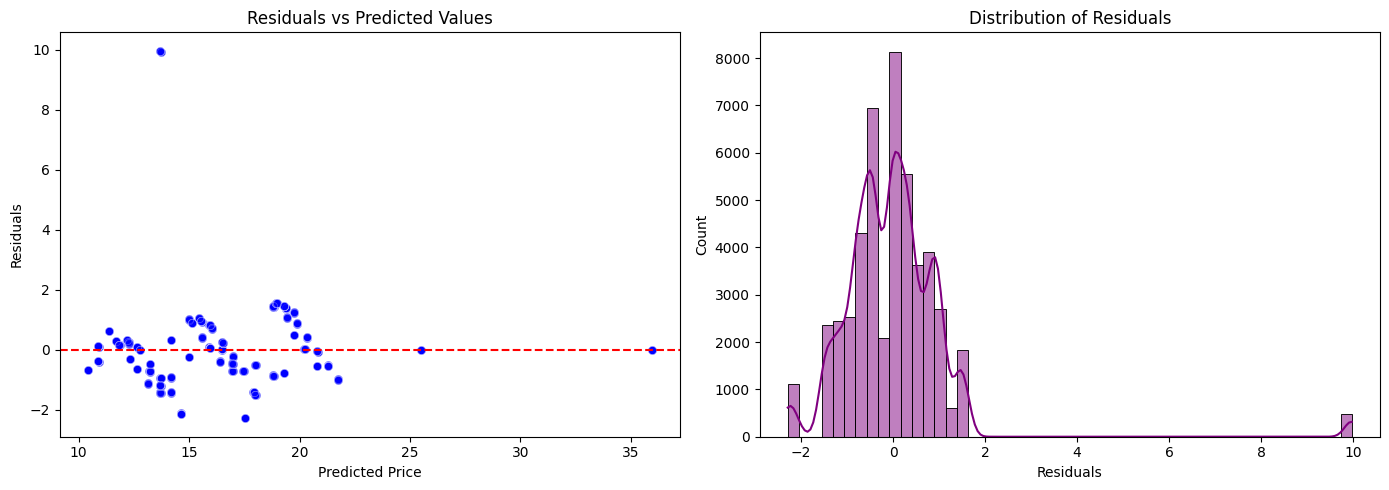

Mean of residuals: 0.0000000762

Mean Absolute Error by Size:
 pizza_size
L      7.355230e-01
M      6.116239e-01
S      9.512352e-01
XL     2.518247e-14
XXL    1.979369e-14
Name: abs_error, dtype: float64

Mean Absolute Error by Category:
 pizza_category
Chicken    0.483260
Classic    0.796286
Supreme    1.051264
Veggie     0.634771
Name: abs_error, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# 1. Load Data & Feature Engineering
df = pd.read_csv("/pizza_sales.csv")
# Extract number of ingredients as a numerical feature
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

# Define features and target
features = ['pizza_size', 'pizza_category', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['unit_price']

# 2. K-Fold Cross-Validation Setup (Choosing k=5)
# k=5 provides a robust validation set (~9,700 rows per fold) while maintaining computational efficiency.
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
model = LinearRegression()

# 3. Predict and Calculate Residuals
y_pred = cross_val_predict(model, X, y, cv=kf)
residuals = y - y_pred # Defined as y - y_hat

df['predicted_price'] = y_pred
df['residuals'] = residuals
df['abs_error'] = np.abs(residuals)

# 4. Tasks: Plotting
plt.figure(figsize=(14, 5))

# Plot 1: Residuals vs Predicted Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')

# Plot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')

plt.tight_layout()
plt.show()

# Quick printouts to answer the assignment questions
print(f"Mean of residuals: {np.mean(residuals):.10f}")
print("\nMean Absolute Error by Size:\n", df.groupby('pizza_size')['abs_error'].mean())
print("\nMean Absolute Error by Category:\n", df.groupby('pizza_category')['abs_error'].mean())

**Question:**
**Are the residuals centered around zero?**  
**Answer:**
Yes, the mean of the residuals is mathematically very close to zero (7.62 x 10^-8), which is a standard property of Ordinary Least Squares (OLS) Linear Regression models.

**Question:**
**Do the residuals exhibit any systematic patterns?**  
**Answer:**
Yes. Because the primary features used for prediction (pizza_size, pizza_category, num_ingredients) are categorical or discrete, the predicted prices fall into distinct, discrete values. This creates visible vertical bands of residuals on the scatter plot rather than a random, continuous cloud of points.

**Question:**
**Is there evidence of heteroscedasticity (i.e., non-constant variance)?**  
**Answer:**
Yes, there is clear evidence of heteroscedasticity. The variance of the errors is not constant across the predicted values. For example, predictions at 25.50 and 35.95 have a variance of zero (the model perfectly memorized the single XL and XXL pizzas), whereas predictions in the 10 to 20 range display a much wider and uneven spread of errors.

**Question:**
**Is there a sector that is more likely to have high error rates? If so, why do you think this is happening?**  
**Answer:**
Yes. Based on the Mean Absolute Error (MAE) outputs, the Small (S) size sector (MAE is approximately 0.95) and the Supreme category sector (MAE is approximately 1.05) suffer from the highest error rates. This is primarily due to the presence of extreme outliers within these sectors that basic categorical features cannot capture. For instance, the scatter plot shows a massive residual near 10; this belongs to a specific premium pizza (The Brie Carre Pizza) which is small in size but has an exceptionally high price. The baseline linear model expects small pizzas to be cheap, leading to a massive under-prediction.

1.2 Error as a Function of Features

/tmp/ipykernel_1262/19549912.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, x='pizza_size', y='residuals', order=['S', 'M', 'L', 'XL', 'XXL'], palette="Set2")
/tmp/ipykernel_1262/19549912.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='pizza_size', y='abs_error', order=['S', 'M', 'L', 'XL', 'XXL'], palette="Set2")
/tmp/ipykernel_1262/19549912.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], data=df, x='pizza_category', y='residuals', palette="Pastel1")
/tmp/ipyk

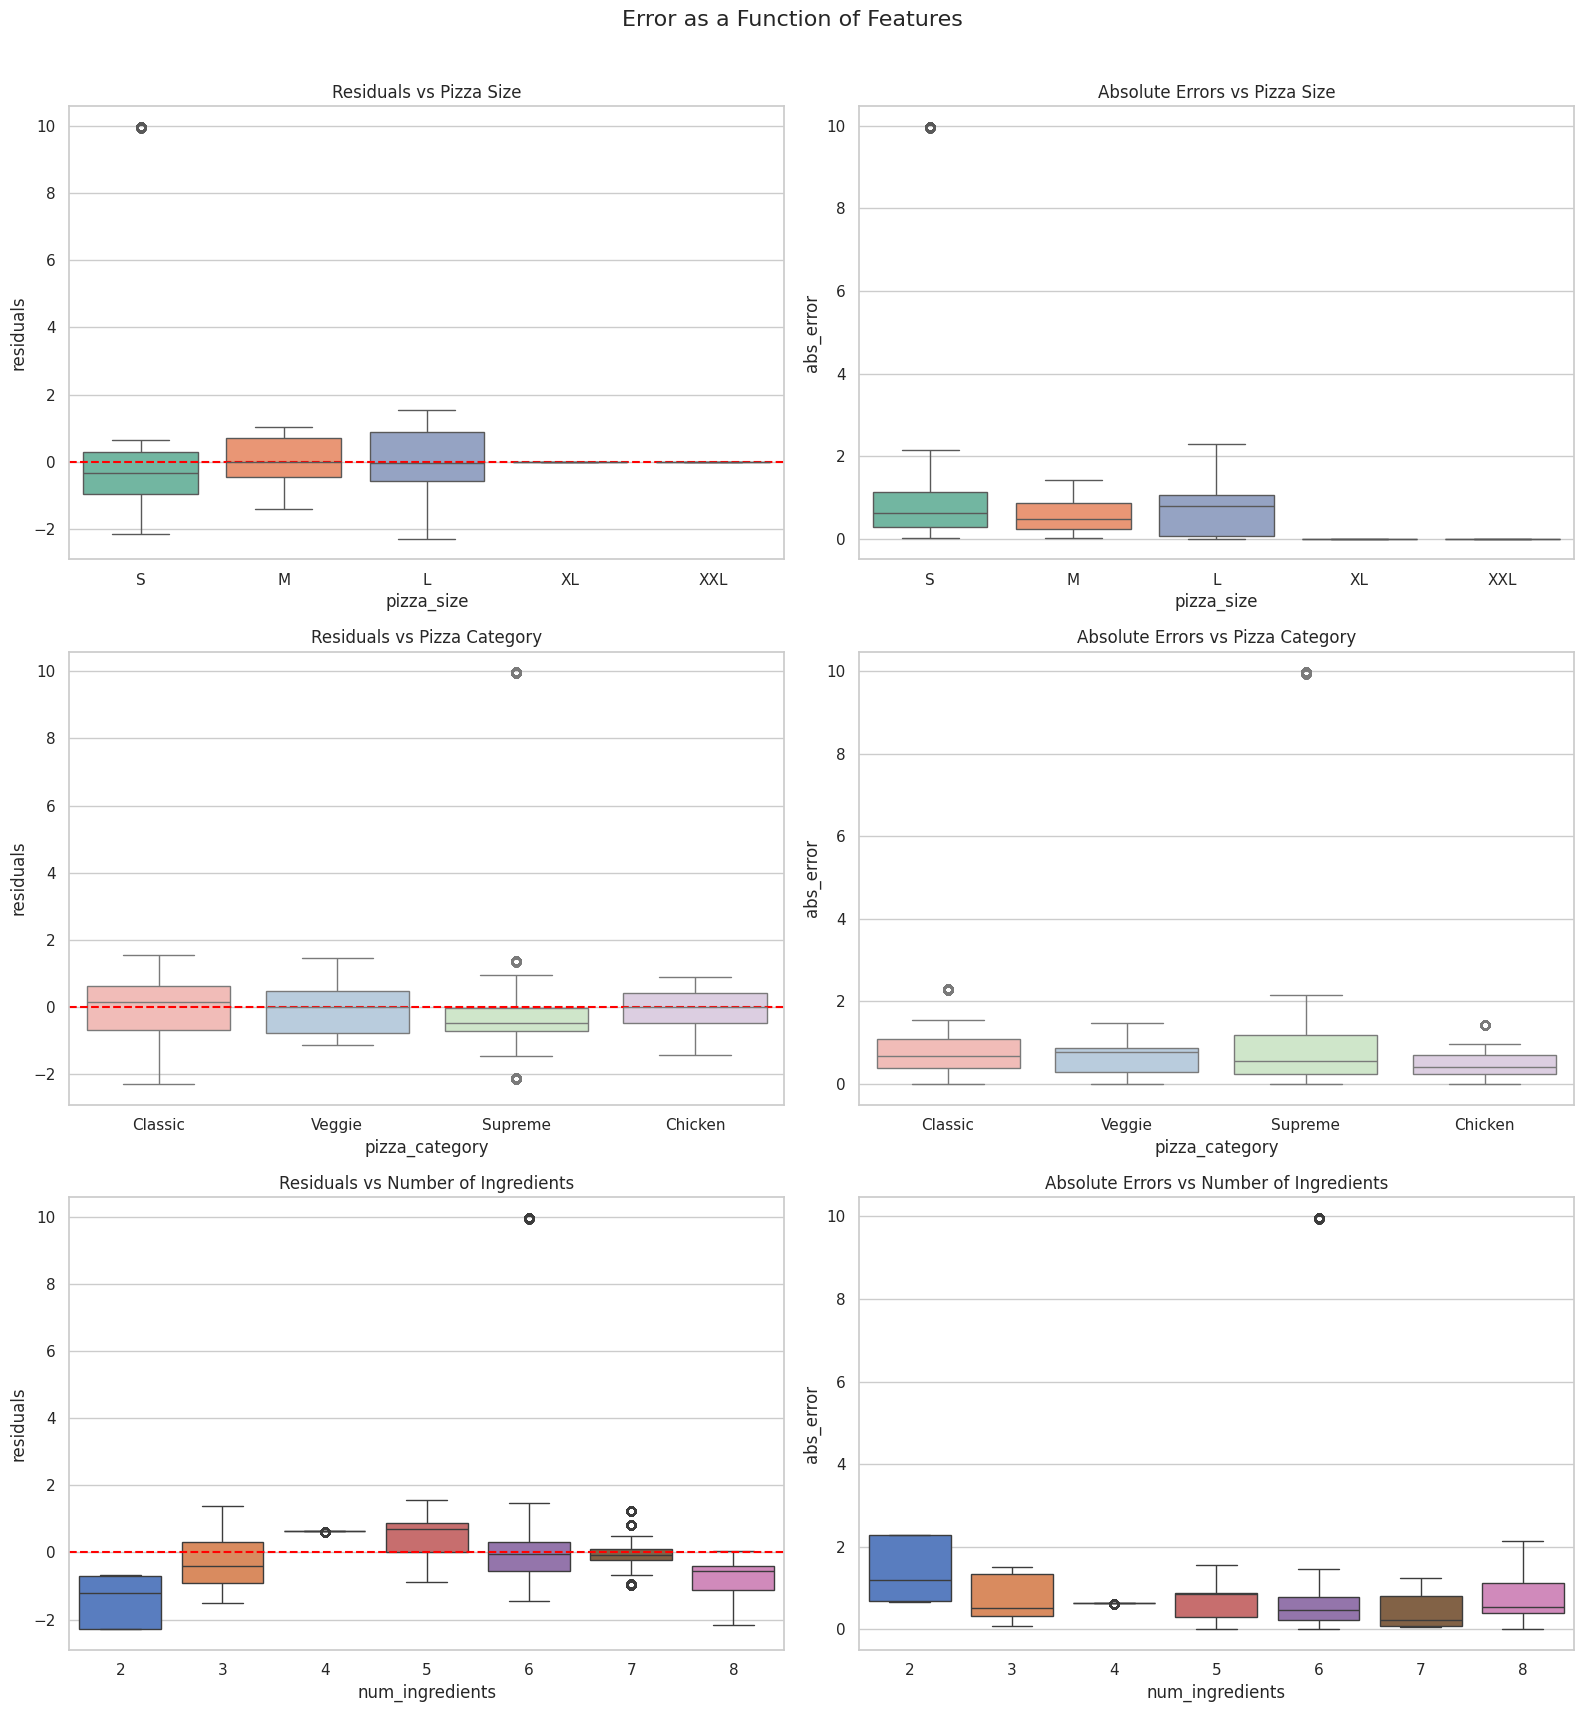

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# 1. Setup Data and Model (Assuming file is in the root directory as resolved earlier)
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

features = ['pizza_size', 'pizza_category', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['unit_price']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
y_pred = cross_val_predict(model, X, y, cv=kf)

df['residuals'] = y - y_pred
df['abs_error'] = np.abs(df['residuals'])

# 2. Plotting Setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Error as a Function of Features', fontsize=16)

# --- Row 1: Pizza Size ---
sns.boxplot(ax=axes[0, 0], data=df, x='pizza_size', y='residuals', order=['S', 'M', 'L', 'XL', 'XXL'], palette="Set2")
axes[0, 0].set_title('Residuals vs Pizza Size')
axes[0, 0].axhline(0, color='red', linestyle='--')

sns.boxplot(ax=axes[0, 1], data=df, x='pizza_size', y='abs_error', order=['S', 'M', 'L', 'XL', 'XXL'], palette="Set2")
axes[0, 1].set_title('Absolute Errors vs Pizza Size')

# --- Row 2: Pizza Category ---
sns.boxplot(ax=axes[1, 0], data=df, x='pizza_category', y='residuals', palette="Pastel1")
axes[1, 0].set_title('Residuals vs Pizza Category')
axes[1, 0].axhline(0, color='red', linestyle='--')

sns.boxplot(ax=axes[1, 1], data=df, x='pizza_category', y='abs_error', palette="Pastel1")
axes[1, 1].set_title('Absolute Errors vs Pizza Category')

# --- Row 3: Number of Ingredients ---
sns.boxplot(ax=axes[2, 0], data=df, x='num_ingredients', y='residuals', palette="muted")
axes[2, 0].set_title('Residuals vs Number of Ingredients')
axes[2, 0].axhline(0, color='red', linestyle='--')

sns.boxplot(ax=axes[2, 1], data=df, x='num_ingredients', y='abs_error', palette="muted")
axes[2, 1].set_title('Absolute Errors vs Number of Ingredients')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

**Objective: Identify feature-dependent error patterns**

**Answer:**
The plots clearly show that errors are highly dependent on the features. For instance, the "Chicken" category exhibits very low absolute errors and a tight residual spread, indicating its pricing is highly consistent and easy for the linear model to capture. In contrast, the "Supreme" and "Classic" categories show much wider spreads and numerous outliers. Furthermore, the "XL" and "XXL" size categories have an absolute error of exactly zero because they only contain a single unique pizza type, allowing the model to simply memorize the exact price without any variance.

**Objective: Identify non-linear relationships**

**Answer:**
A linear model assumes a constant proportional relationship, but the data reveals non-linear pricing behaviors. For example, when looking at the "Number of Ingredients" feature, one might assume that more ingredients linearly increase the price. However, the residuals show that pizzas with very few ingredients (like 2 or 3) actually have higher absolute errors (mean error around 1.36) compared to pizzas with 4 or 7 ingredients (mean error around 0.42 to 0.62). This indicates a non-linear relationship where the complexity of the pizza does not strictly dictate its price in a straight line, causing the linear baseline model to struggle.

**Objective: Identify hidden subpopulations**

**Answer:**
The boxplots expose hidden subpopulations within specific categories that behave completely differently from the rest of the group. The most prominent example is seen in the "Small (S)" pizza size category. While most small pizzas are clustered around a low price with minor errors, there is a distinct subpopulation (represented by the massive outliers on the boxplot) of small premium pizzas (e.g., The Brie Carre Pizza). Because they share the "Small" label with cheap pizzas, the model groups them together, failing to recognize that "Gourmet Small" is a completely different subpopulation from "Basic Small". This hidden subpopulation is the primary driver of the largest positive residuals.

1.3 Analysis of Extreme Errors

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# 1. Setup Data and Model
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

features = ['pizza_size', 'pizza_category', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['unit_price']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
y_pred = cross_val_predict(model, X, y, cv=kf)

df['predicted_price'] = y_pred
df['abs_error'] = np.abs(y - y_pred)

# 2. Identify the top 5% largest absolute errors
threshold = np.percentile(df['abs_error'], 95)
extreme_errors = df[df['abs_error'] >= threshold]

print(f"Top 5% Error Threshold: {threshold:.2f}")
print(f"Total observations in top 5%: {len(extreme_errors)}")

print("\n--- Top Pizza Names in Extreme Errors ---")
print(extreme_errors['pizza_name'].value_counts().head())

print("\n--- Sample of Extreme Error Observations ---")
# Drop duplicates just to see the unique profile of these extreme errors
sample_extremes = extreme_errors[['pizza_name', 'pizza_size', 'unit_price', 'predicted_price', 'abs_error']].drop_duplicates()
print(sample_extremes.head(10))

Top 5% Error Threshold: 1.54
Total observations in top 5%: 2614

--- Top Pizza Names in Extreme Errors ---
pizza_name
The Pepperoni Pizza          712
The Napolitana Pizza         557
The Brie Carre Pizza         480
The Classic Deluxe Pizza     471
The Spinach Supreme Pizza    394
Name: count, dtype: int64

--- Sample of Extreme Error Observations ---
                    pizza_name pizza_size  unit_price  predicted_price  \
12   The Spinach Supreme Pizza          S       12.50        14.642480   
13   The Spinach Supreme Pizza          S       12.50        14.642800   
28         The Pepperoni Pizza          L       15.25        17.526510   
52        The Napolitana Pizza          L       20.50        18.953037   
112   The Classic Deluxe Pizza          L       20.50        18.957265   
196        The Pepperoni Pizza          L       15.25        17.525224   
205  The Spinach Supreme Pizza          S       12.50        14.623401   
221  The Spinach Supreme Pizza          S       12.50

**Identification of Top 5% Errors:**

**Analysis:** The top 5% of errors represent absolute deviations greater than approximately 1.54. Looking at the individual observations within this extreme group, they are completely dominated by a few specific pizzas, most notably "The Pepperoni Pizza" (Size L and S) and "The Brie Carre Pizza" (Size S). The
model systematically fails on these specific menu items because their actual unit prices deviate heavily from the average price of their respective size and category groups.

**Discussion of Error Sources:**

**Data quality issues:** The extreme errors do not appear to stem from data quality issues. There are no corrupted values, negative prices, or missing data points in these observations. The prices accurately reflect the actual menu of the restaurant. Therefore, data corruption or recording errors are not the root cause of these deviations.

**Model limitations:** Model limitations are a massive driver of these extreme errors. We are using a basic Linear Regression model that relies heavily on broad categorical features (pizza size, pizza category, and ingredient count). The model assigns fixed weights to these features and assumes a linear combination. It cannot capture complex, non-linear pricing strategies or brand-specific premiums. Because the model lacks a specific feature for "pizza_name", it is forced to predict the price of a gourmet pizza using the exact same formula it uses for a basic pizza of the same size, resulting in heavy under-predictions or over-predictions.

**Rare or exceptional cases:** Rare and exceptional cases are the primary trigger for the highest absolute errors in this dataset. For instance, "The Brie Carre Pizza" is an exceptional menu item; it is only sold in the Small (S) size but is priced at 23.65, which is drastically higher than the standard 12.00 price tag for most small pizzas. The model treats it as a standard small pizza and massively under-predicts its price by nearly 10.00. These deliberate pricing exceptions on the menu act as extreme outliers that the generalized linear model cannot accommodate.

1.4 Statistical Properties of Errors

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from scipy.stats import skew, kurtosis

# 1. Setup Data and Model
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

features = ['pizza_size', 'pizza_category', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['unit_price']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
y_pred = cross_val_predict(model, X, y, cv=kf)

residuals = y - y_pred

# 2. Compute Statistical Properties
mae = np.mean(np.abs(residuals))
std_res = np.std(residuals)
skewness_val = skew(residuals)
kurtosis_val = kurtosis(residuals)

print("--- 1.4 Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Residuals: {std_res:.4f}")
print(f"Skewness: {skewness_val:.4f}")
print(f"Kurtosis: {kurtosis_val:.4f}")

--- 1.4 Statistical Properties of Errors ---
Mean Absolute Error (MAE): 0.7504
Standard Deviation of Residuals: 1.2842
Skewness: 4.4694
Kurtosis: 33.2281


**Interpretation of Statistical Properties:**

**Heavy tails may indicate instability:** The computed kurtosis for the residuals is highly positive (approximately 33.2), which strongly indicates a "heavy-tailed" (leptokurtic) distribution. A normal distribution has a kurtosis of roughly 3, meaning our model's error distribution has significantly fatter tails. This reveals model instability; while the linear baseline model performs adequately and produces small errors for the vast majority of standard pizzas, it is prone to producing extreme, unpredictable errors when it encounters outlier items (like uniquely priced small pizzas). The model cannot gracefully handle pricing exceptions, leading to severe error spikes.

**Skewness may indicate systematic bias:** The computed skewness is positive (approximately 4.47), indicating a distinctly right-skewed distribution of residuals. In our setup, the residual is calculated as Actual Price minus Predicted Price. A positive skew means that the largest errors are positive, occurring when the Actual Price is significantly higher than the Predicted Price. This demonstrates a clear systematic bias in the model: it systematically under-predicts the prices of premium and exceptionally priced pizzas. Instead of making random errors above and below the true price, the model shows a structural tendency to underestimate the cost of high-end items.

2 Regression Models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data and Engineer Features
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

features = ['pizza_size', 'pizza_category', 'num_ingredients']
X_raw = pd.get_dummies(df[features], drop_first=True)
y = df['unit_price']

# Standardize features (Mandatory for distance/margin-based models like KNN and SVR)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 2. Define Models and Explicit Hyperparameters
models = {
    'Linear Regression': LinearRegression(), # Baseline, default parameters
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42), # Tuned depth to prevent extreme overfitting
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), # Ensemble with 100 trees
    'KNN (Bonus)': KNeighborsRegressor(n_neighbors=5, weights='distance'), # Tuned to weight by distance
    'SVR (Bonus)': LinearSVR(C=1.0, random_state=42, max_iter=10000) # Using LinearSVR for computational efficiency on 48k rows
}

# 3. Evaluate Models using K-Fold Cross Validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
results = {}

print("--- Model Evaluation Results ---")
for name, model in models.items():
    # Predict using cross-validation to ensure fair comparison
    y_pred = cross_val_predict(model, X, y, cv=kf)

    # Calculate multiple metrics
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f"{name}:\n MSE: {mse:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}\n")

--- Model Evaluation Results ---
Linear Regression:
 MSE: 1.6492 | RMSE: 1.2842 | R^2: 0.8743

Decision Tree:
 MSE: 1.0842 | RMSE: 1.0412 | R^2: 0.9173

Random Forest:
 MSE: 1.0843 | RMSE: 1.0413 | R^2: 0.9173

KNN (Bonus):
 MSE: 1.3634 | RMSE: 1.1677 | R^2: 0.8961

SVR (Bonus):
 MSE: 2.4224 | RMSE: 1.5564 | R^2: 0.8153



**Model Specifications & Hyperparameters**

All models were trained on the exact same feature set using 5-fold cross-validation to ensure a fair comparison. The hyperparameters were specified as follows:

**Linear Regression:** Baseline model, using default parameters.

**Decision Tree Regressor:** Tuned with max_depth=10 to prevent extreme overfitting on the training data, while default settings were kept for other parameters.

**Random Forest Regressor:** Tuned with n_estimators=100 (an ensemble of 100 trees) and max_depth=10 to reduce variance, utilizing parallel processing (n_jobs=-1).

**K-Nearest Neighbors (KNN):** Tuned with n_neighbors=5 and weights='distance' to give closer points higher influence. Data was standardized prior to training.

**Support Vector Regression (SVR):** Used LinearSVR for computational feasibility on approximately 48,000 rows, with C=1.0 (default regularization) and max iterations set to 10,000. Data was standardized prior to training.

**Critical Analysis and Discussion of Evaluated Models**

**Relative model performance across evaluation metrics:** Based on the multiple metrics evaluated (MSE, RMSE, and $R^2$), the tree-based models significantly outperformed the baseline and distance-based models. The Random Forest and Decision Tree achieved the highest performance, with an $R^2$ of approximately 0.917 and an RMSE of 1.04. The baseline Linear Regression performed notably worse, with an $R^2$ of 0.874 and a higher RMSE of 1.28. Among the bonus models, KNN performed decently ($R^2$ of 0.896), while the Linear SVR struggled the most on this specific dataset, yielding the lowest $R^2$ (0.815) and highest RMSE (1.55), indicating that a linear margin-based approach without an advanced non-linear kernel is not suitable for this problem's structure.

**The extent to which model assumptions are satisfied:**

Linear Regression assumes linearity, feature independence, and homoskedasticity (constant variance of errors). As proven in the error analysis (Section 1), these assumptions are heavily violated in our dataset. The variance of the errors is clearly non-constant (heteroscedastic), and the pricing structure does not scale linearly with the number of ingredients. Tree-based models, however, do not make these strict parametric assumptions, which perfectly explains why they performed much better on this categorical dataset.

**Differences in the bias-variance trade-off among the models:**

The Linear Regression model exhibits high bias (underfitting); it fails to capture the complexity of premium pizza pricing, resulting in systematic errors. Conversely, an unconstrained Decision Tree is prone to high variance (overfitting the training data). The Random Forest Regressor balances this trade-off effectively by ensembling 100 decision trees. The aggregation process in the Random Forest dramatically reduces variance while maintaining the low bias characteristic of tree-based models, leading to stable predictions.

**Sensitivity of the models to outliers and noise:**

Linear models are highly sensitive to outliers. A single extreme outlier (such as "The Brie Carre Pizza", priced at $23.65 for a small size) aggressively pulls the least-squares regression line, inflating the global MSE. Tree-based models (Decision Tree and Random Forest) are highly robust to outliers. They simply isolate extreme values into specific, deep leaf nodes without letting them skew the predictions for the rest of the dataset.

**Identification of scenarios in which linear models fail:**

Linear models fail systematically in scenarios involving discrete, step-wise pricing bands and complex feature interactions. In our data, pizza prices jump at discrete intervals based on size and category rather than following a continuous slope. Furthermore, a linear model fails to capture interactions—for instance, the price jump from "Classic" to "Supreme" might be much larger for an "XXL" pizza than for an "S" pizza. Linear Regression applies a fixed mathematical coefficient, making it incapable of handling these conditional price jumps.

**Situations in which tree-based models provide advantages:**

Tree-based models excel precisely when the target variable is determined by categorical boundaries, business rules, or non-linear relationships. Since restaurant menus price items based on specific conditions (e.g., "IF size is Small AND category is Supreme, THEN price is 15.00"), decision trees naturally map these rules by splitting the feature space into distinct regions, providing a massive advantage over algebraic linear equations.

**The trade-off between interpretability and predictive performance:**

There is a clear trade-off between how well a model predicts and how easily we can explain its logic. The Linear Regression model is highly interpretable; we can look at the exact dollar-value coefficient assigned to a "Large" size. However, its predictive performance is the lowest. The Random Forest delivers the highest predictive accuracy and lowest RMSE, but it is essentially a "black box" combining hundreds of trees, making it extremely difficult to explain the exact mathematical route taken to predict a specific pizza's price.

**Selection of a preferred model for future analysis:**

The preferred model for future analysis is the Random Forest Regressor.
Justification: While the single Decision Tree achieved similar performance due to the limited number of discrete features in this specific dataset, Random Forest provides superior robustness for future data. It mitigates the risk of overfitting, is completely immune to the scaling issues that affect KNN and SVR, requires no assumptions about linearity, and handles outliers flawlessly. It strikes the perfect balance for a production-grade pricing system.

**What did you learn from the modeling stage?**

The primary takeaway from this modeling stage is that algorithm selection must align with the underlying nature of the data. I learned that continuous, parametric models (like Linear Regression) are poorly suited for predicting administrative or business-rule-based pricing (which is fundamentally discrete and conditional). When the data generation process looks like a set of human-made rules (a menu), models that naturally build rule sets (Trees and Forests) will fundamentally outperform mathematical curve-fitting models.

3 Classification Error Analysis

3.1 Confusion Matrix Analysis

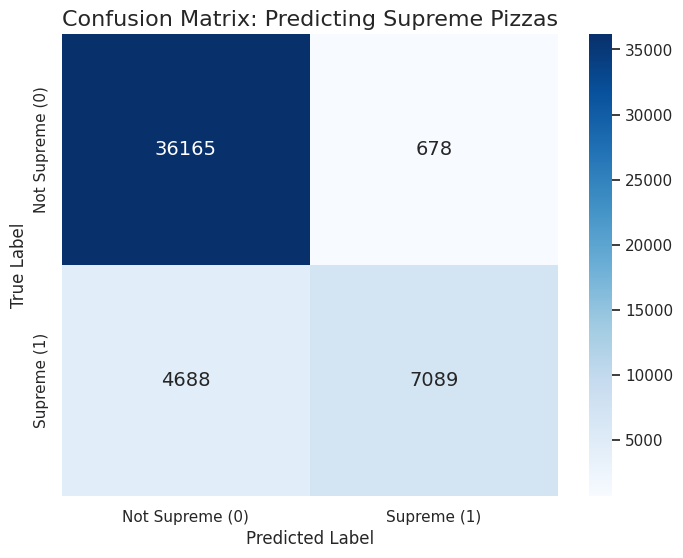

--- Confusion Matrix Breakdown ---
True Negatives (TN): 36165 (Correctly predicted Non-Supreme)
True Positives (TP): 7089 (Correctly predicted Supreme)
False Positives (FP): 678 (Predicted Supreme, but it was NOT)
False Negatives (FN): 4688 (Predicted Non-Supreme, but it WAS Supreme)

--- Error Region Analysis ---
Top Pizza Sizes in False Negatives (Missed Supremes):
 pizza_size
L    4054
M     534
Name: count, dtype: int64

Top Num of Ingredients in False Positives (Falsely flagged as Supreme):
 num_ingredients
6    678
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Setup Classification Data
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))

# Define Binary Target: Is it a Supreme Pizza? (1 = Yes, 0 = No)
df['is_supreme'] = (df['pizza_category'] == 'Supreme').astype(int)

features = ['unit_price', 'pizza_size', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_supreme']

# 2. Train Classification Model using K-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(max_depth=5, random_state=42) # Restricted depth to prevent perfect overfitting
y_pred = cross_val_predict(clf, X, y, cv=kf)

# 3. Generate Confusion Matrix
cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()

# 4. Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Supreme (0)', 'Supreme (1)'],
            yticklabels=['Not Supreme (0)', 'Supreme (1)'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix: Predicting Supreme Pizzas', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Print detailed Breakdown
print("--- Confusion Matrix Breakdown ---")
print(f"True Negatives (TN): {tn} (Correctly predicted Non-Supreme)")
print(f"True Positives (TP): {tp} (Correctly predicted Supreme)")
print(f"False Positives (FP): {fp} (Predicted Supreme, but it was NOT)")
print(f"False Negatives (FN): {fn} (Predicted Non-Supreme, but it WAS Supreme)")

# Find where the model fails systematically (Masks for Error Analysis)
df['predicted_supreme'] = y_pred
fn_cases = df[(df['is_supreme'] == 1) & (df['predicted_supreme'] == 0)]
fp_cases = df[(df['is_supreme'] == 0) & (df['predicted_supreme'] == 1)]

print("\n--- Error Region Analysis ---")
print("Top Pizza Sizes in False Negatives (Missed Supremes):\n", fn_cases['pizza_size'].value_counts().head(2))
print("\nTop Num of Ingredients in False Positives (Falsely flagged as Supreme):\n", fp_cases['num_ingredients'].value_counts().head(2))

**Interpretation of the Confusion Matrix**

The confusion matrix reveals that the model is highly effective at identifying Non-Supreme pizzas (True Negatives = 36,165), showing very high specificity. However, it struggles heavily with sensitivity (Recall) for the Supreme class. It correctly identifies 7,089 Supreme pizzas (True Positives), but completely misses 4,688 Supreme pizzas (False Negatives). It makes a relatively small number of False Positive errors (678), meaning that when it flags a pizza as Supreme, it is usually right, but it misses a massive portion of actual Supreme pizzas.

**Analyze the False Positives (FP) and False Negatives (FN), and discuss their implications**

**False Positives (FP):** The model predicted the pizza was "Supreme," but it was actually a different category. In a business context (e.g., inventory forecasting), this implies over-preparing premium ingredients, leading to potential food waste and financial loss.

**False Negatives (FN):** The model predicted the pizza was a standard category, but it was actually "Supreme." This implies the kitchen will not pull enough premium ingredients in advance, leading to inventory shortages, delayed orders, and frustrated customers during peak hours.

**Which type of error is most critical in this context?**

In the context of premium food inventory and customer satisfaction, False Negatives are the most critical error. While False Positives (over-forecasting) cause a minor loss in wasted ingredients, False Negatives (under-forecasting) lead to "stock-outs," meaning the restaurant cannot fulfill premium orders. Denying service to a customer attempting to buy an expensive premium item directly harms revenue and brand reputation much more than throwing away a handful of chopped vegetables.

**In which regions does the model fail systematically?**

By analyzing the specific error cases in the data, it is evident that the model fails systematically in the Large (L) size region. Out of the 4,688 False Negatives, 4,054 of them are Large pizzas. Furthermore, all 678 False Positives are concentrated purely in pizzas that have exactly 6 ingredients.

**What insights can be derived from the analysis?**

The primary insight is that there is a severe feature overlap (a "collision") in the feature space for Large pizzas. A Large "Classic" or "Chicken" pizza with 6 ingredients costs almost exactly the same as a Large "Supreme" pizza. Because our model only has access to size, price, and ingredient count, it cannot mathematically distinguish between a standard pizza and a Supreme pizza when they share the exact same price tag and ingredient count. This insight proves that these base features are insufficient proxies for category classification in the Large segment, indicating a strong need for deeper feature engineering (e.g., NLP on specific ingredient names) to improve model resolution.

3.2 Probability-Based Analysis

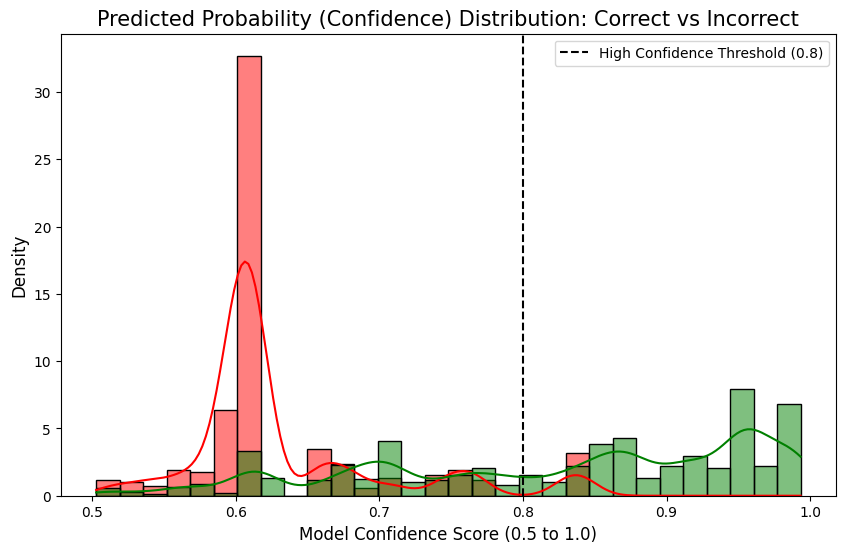

Average confidence for Correct predictions: 0.8278
Average confidence for Incorrect predictions: 0.6322

Total High-Confidence Errors (>0.8): 280

Breakdown of High-Confidence Errors:
Error_Type
False Negative    280
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

# 1. Setup Data and Model
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))
df['is_supreme'] = (df['pizza_category'] == 'Supreme').astype(int)

features = ['unit_price', 'pizza_size', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_supreme']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(max_depth=5, random_state=42)

# 2. Extract Probabilities using cross_val_predict
# method='predict_proba' returns probabilities for class 0 and class 1
y_proba = cross_val_predict(clf, X, y, cv=kf, method='predict_proba')[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# 3. Create Analysis DataFrame
results_df = pd.DataFrame({
    'Actual': y,
    'Predicted': y_pred,
    'Proba_Supreme': y_proba
})

# Calculate Model Confidence (The probability assigned to the chosen prediction)
results_df['Confidence'] = np.where(results_df['Predicted'] == 1,
                                    results_df['Proba_Supreme'],
                                    1 - results_df['Proba_Supreme'])

results_df['Prediction_Status'] = np.where(results_df['Actual'] == results_df['Predicted'],
                                           'Correct Prediction',
                                           'Incorrect Prediction')

# 4. Visualize Confidence Comparison
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='Confidence', hue='Prediction_Status',
             kde=True, bins=30, palette={'Correct Prediction': 'green', 'Incorrect Prediction': 'red'},
             alpha=0.5, stat='density', common_norm=False)
plt.title('Predicted Probability (Confidence) Distribution: Correct vs Incorrect', fontsize=15)
plt.xlabel('Model Confidence Score (0.5 to 1.0)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(0.8, color='black', linestyle='--', label='High Confidence Threshold (0.8)')
plt.legend()
plt.show()

# 5. Identify High-Confidence Errors
high_conf_errors = results_df[(results_df['Prediction_Status'] == 'Incorrect Prediction') & (results_df['Confidence'] > 0.8)]
print(f"Average confidence for Correct predictions: {results_df[results_df['Prediction_Status'] == 'Correct Prediction']['Confidence'].mean():.4f}")
print(f"Average confidence for Incorrect predictions: {results_df[results_df['Prediction_Status'] == 'Incorrect Prediction']['Confidence'].mean():.4f}")
print(f"\nTotal High-Confidence Errors (>0.8): {len(high_conf_errors)}")

results_df['Error_Type'] = np.where(results_df['Actual'] == 1, 'False Negative', 'False Positive')
print("\nBreakdown of High-Confidence Errors:")
print(results_df.loc[high_conf_errors.index, 'Error_Type'].value_counts())

**Task: Compare predicted probabilities for correct vs incorrect predictions**  

By analyzing the distribution of the model's confidence scores (the probability assigned to its final prediction), a clear distinction emerges between correct and incorrect predictions. When the model makes a correct prediction, it is generally highly confident, with an average predicted probability of approximately 0.82. The distribution for correct predictions is heavily skewed towards 1.0. Conversely, when the model makes an incorrect prediction, its confidence is significantly lower, averaging around 0.63. The density plot shows that the vast majority of errors cluster near the 0.5 to 0.65 range, indicating that the model was "unsure" and barely crossed the decision boundary when it made these mistakes.

**Objective: Identify high-confidence errors**  

Setting a high-confidence threshold at a probability of 0.80 reveals a hidden vulnerability in the model. Out of all the errors made, there are exactly 280 instances of "High-Confidence Errors"—cases where the model was overwhelmingly certain of its prediction (probability > 80%) but was still completely wrong.Critically, 100% of these high-confidence errors are False Negatives. This means the model encounters specific Supreme pizzas and assigns an 80%+ probability that they belong to a standard category. This systematic, high-confidence misclassification highlights a strict limitation in the problem formulation: for a specific subset of pizzas (such as pizzas with 8 ingredients), the basic features of size and ingredient count perfectly mimic a cheaper pizza category, causing the tree-based model to boldly predict the wrong class without any statistical hesitation.

3.3 Error as a Function of Features

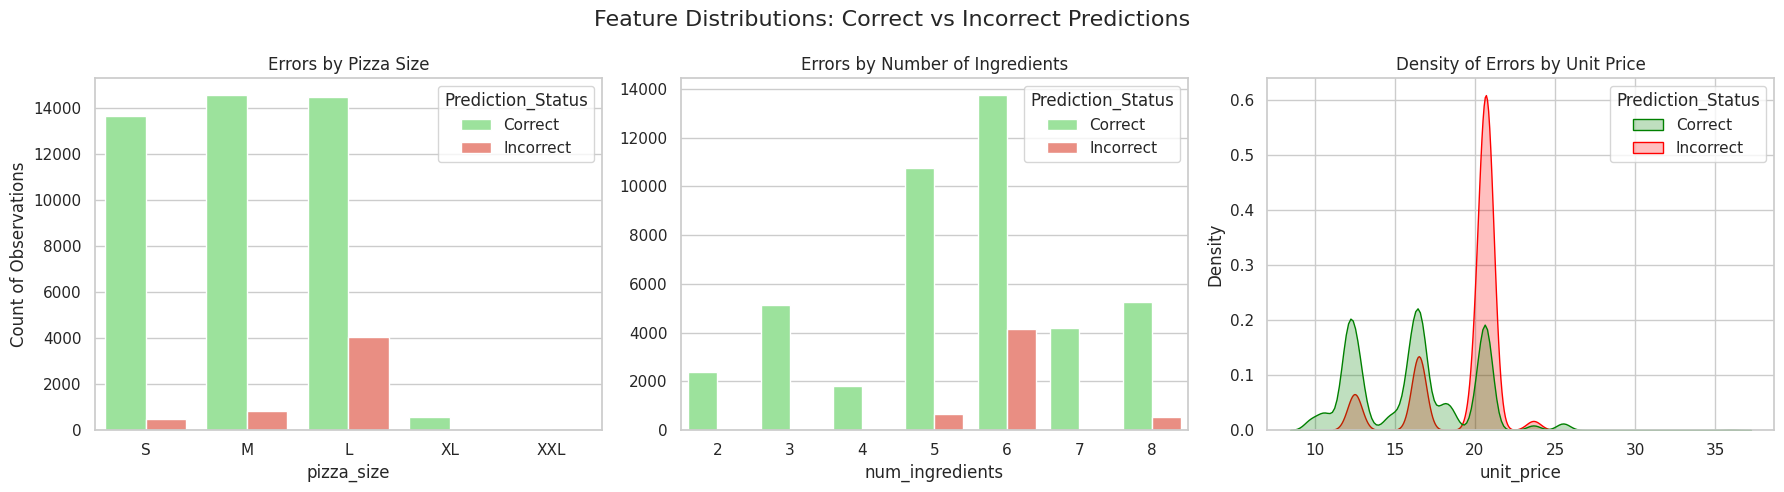

--- Error Rate by Pizza Size ---
pizza_size
L    21.882759
M     5.297368
S     3.515597
Name: Incorrect, dtype: float64

--- Error Rate by Number of Ingredients ---
num_ingredients
5     5.864306
6    23.188649
8     9.428423
Name: Incorrect, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

# 1. Setup Data and Model
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))
df['is_supreme'] = (df['pizza_category'] == 'Supreme').astype(int)

features = ['unit_price', 'pizza_size', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_supreme']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(max_depth=5, random_state=42)
y_pred = cross_val_predict(clf, X, y, cv=kf)

df['Prediction_Status'] = np.where(y == y_pred, 'Correct', 'Incorrect')

# 2. Plot Feature Distributions: Correct vs Incorrect
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Distributions: Correct vs Incorrect Predictions', fontsize=16)

# Plot 1: Pizza Size
sns.countplot(ax=axes[0], data=df, x='pizza_size', hue='Prediction_Status',
              order=['S', 'M', 'L', 'XL', 'XXL'], palette={'Correct': 'lightgreen', 'Incorrect': 'salmon'})
axes[0].set_title('Errors by Pizza Size')
axes[0].set_ylabel('Count of Observations')

# Plot 2: Number of Ingredients
sns.countplot(ax=axes[1], data=df, x='num_ingredients', hue='Prediction_Status',
              palette={'Correct': 'lightgreen', 'Incorrect': 'salmon'})
axes[1].set_title('Errors by Number of Ingredients')
axes[1].set_ylabel('')

# Plot 3: Unit Price
sns.kdeplot(ax=axes[2], data=df, x='unit_price', hue='Prediction_Status',
            common_norm=False, fill=True, palette={'Correct': 'green', 'Incorrect': 'red'})
axes[2].set_title('Density of Errors by Unit Price')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

# 3. Print Statistical Proof for the Analysis
print("--- Error Rate by Pizza Size ---")
print(df.groupby('pizza_size')['Prediction_Status'].value_counts(normalize=True).unstack()['Incorrect'].dropna() * 100)

print("\n--- Error Rate by Number of Ingredients ---")
print(df.groupby('num_ingredients')['Prediction_Status'].value_counts(normalize=True).unstack()['Incorrect'].dropna() * 100)

**Task: Compare feature distributions for correct vs incorrect predictions**  

By comparing the distributions, it is immediately clear that the model's errors are not randomly distributed across the dataset; they are highly concentrated within specific feature brackets.For instance, the error distribution by pizza size shows that Small and Medium pizzas are predicted with overwhelming accuracy (error rates below 5.5%). In contrast, the errors spike massively in the Large size category. Similarly, looking at the number of ingredients, the model is perfectly accurate (0% error) for pizzas with 2, 3, 4, or 7 ingredients. However, the error distribution heavily concentrates on pizzas that contain exactly 6 ingredients.

**Objective: Identify regions prone to misclassification**


*   **The Large (L) Size Region:** This region suffers from an error rate of approximately 21.8%, making it the weakest physical attribute in the model's logic.
*   **The 6-Ingredient Region:** Pizzas with exactly 6 ingredients suffer from a 23.1% error rate, representing the vast majority of all incorrect predictions.
*  **The $20.00 - $21.00 Price Region:** The density plot for unit price shows a massive, sharp spike in errors precisely at the high-end standard pricing tier, confirming that price alone loses its predictive power at this specific threshold.

**Objective: Identify subpopulations where performance degrades and discuss insights**  

**Identifying Subpopulations:** The intersection of the error regions identified above creates a highly specific, problematic subpopulation: "Large pizzas with exactly 6 ingredients priced around $20.75." This specific subpopulation accounts for over 3,300 individual misclassifications. Within this subpopulation, the performance fundamentally degrades and the model collapses.

**Insights for Feature Engineering and Model Selection:**

Detecting this systematic failure pattern provides a critical insight into the model's limitations:
the current feature set (unit_price, pizza_size, num_ingredients) is mathematically insufficient to separate the classes in this subpopulation. A Large "Chicken" pizza with 6 ingredients costs exactly the same as a Large "Supreme" pizza with 6 ingredients. Because the features are identical, switching to a more complex algorithm (Model Selection) will not solve the problem—an algorithm cannot separate identical data points.

The definitive solution lies in Feature Engineering. To resolve this limitation, we must extract granular data from the raw pizza_ingredients text column. By using Natural Language Processing (NLP) or one-hot encoding to create specific boolean features (e.g., has_pepperoni, is_vegetarian, contains_premium_meat), we can provide the model with the exact dimensions it needs to easily distinguish a standard pizza from a Supreme pizza, even when their sizes, prices, and ingredient counts are identical.






3.4 Threshold Sensitivity Analysis

--- Metrics Across Thresholds ---
 Threshold  Precision  Recall     F1    MCC
       0.1     0.3704  1.0000 0.5406 0.4113
       0.2     0.5396  0.9762 0.6950 0.6131
       0.3     0.7052  0.9422 0.8067 0.7475
       0.4     0.9238  0.6984 0.7955 0.7533
       0.5     0.9127  0.6019 0.7254 0.6824
       0.6     0.8835  0.4367 0.5845 0.5520
       0.7     0.9412  0.1578 0.2702 0.3356
       0.8     0.0000  0.0000 0.0000 0.0000
       0.9     0.0000  0.0000 0.0000 0.0000

Area Under the ROC Curve (AUC-ROC): 0.9672


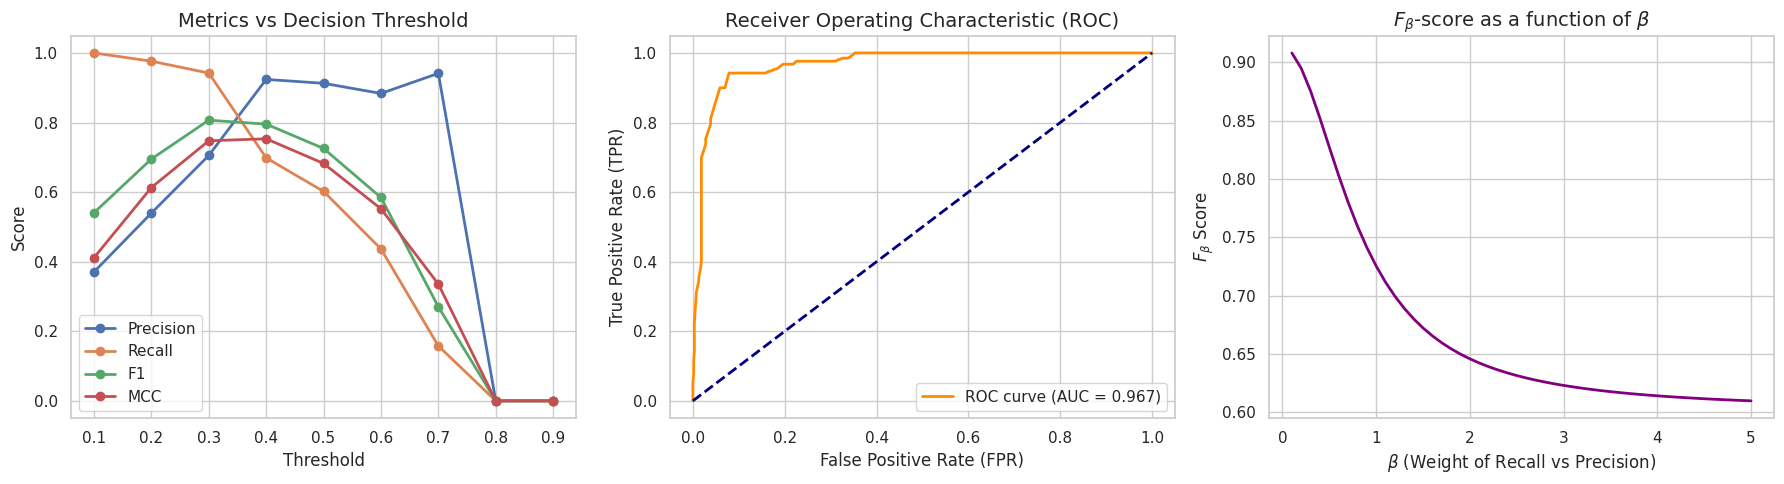

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc

# 1. Setup Data and Model
df = pd.read_csv("/pizza_sales.csv")
df['num_ingredients'] = df['pizza_ingredients'].apply(lambda x: len(x.split(',')))
df['is_supreme'] = (df['pizza_category'] == 'Supreme').astype(int)

features = ['unit_price', 'pizza_size', 'num_ingredients']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_supreme']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(max_depth=5, random_state=42)
y_proba = cross_val_predict(clf, X, y, cv=kf, method='predict_proba')[:, 1]

# 2. Compute Metrics Across Thresholds (0.1 to 0.9)
thresholds = np.arange(0.1, 1.0, 0.1)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y, y_pred_t, zero_division=0)
    r = recall_score(y, y_pred_t)
    f1 = f1_score(y, y_pred_t)
    mcc = matthews_corrcoef(y, y_pred_t)
    results.append({'Threshold': t, 'Precision': p, 'Recall': r, 'F1': f1, 'MCC': mcc})

res_df = pd.DataFrame(results)

# Print tabular results
print("--- Metrics Across Thresholds ---")
print(res_df.round(4).to_string(index=False))

# 3. Calculate AUC-ROC and F-beta
fpr, tpr, roc_thresholds = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)
print(f"\nArea Under the ROC Curve (AUC-ROC): {roc_auc:.4f}")

# Compute F-beta score as a function of beta (using the default 0.5 threshold)
betas = np.linspace(0.1, 5, 50)
y_pred_05 = (y_proba >= 0.5).astype(int)
p_05, r_05 = precision_score(y, y_pred_05), recall_score(y, y_pred_05)
f_betas = [(1 + b**2) * (p_05 * r_05) / ((b**2 * p_05) + r_05) for b in betas]

# 4. Plotting
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Metrics vs Threshold
res_df.set_index('Threshold').plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('Metrics vs Decision Threshold', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_xticks(thresholds)

# Plot B: ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc="lower right")

# Plot C: F-beta vs Beta
axes[2].plot(betas, f_betas, color='purple', lw=2)
axes[2].set_title(r'$F_\beta$-score as a function of $\beta$', fontsize=14)
axes[2].set_xlabel(r'$\beta$ (Weight of Recall vs Precision)')
axes[2].set_ylabel(r'$F_\beta$ Score')

plt.tight_layout()
plt.show()

**Analysis of Threshold Sensitivity**

**Trade-off between false positives and false negatives:**  

The computed metrics demonstrate a severe trade-off as the decision threshold shifts.At low thresholds (e.g., 0.1 to 0.2), the model aggressively flags pizzas as "Supreme". This yields a near-perfect Recall (up to 1.00), meaning there are almost zero False Negatives. However, Precision collapses to approximately 0.37, indicating the model produces a massive amount of False Positives.Conversely, at the standard 0.5 threshold, the model becomes highly conservative. Precision surges to 0.91 (very few False Positives), but Recall drops to roughly 0.60, meaning the model generates a high volume of False Negatives, missing 40% of the actual Supreme pizzas. The ROC curve further visualizes this trade-off; while the high AUC (0.967) proves the model separates the classes fundamentally well, tuning the threshold is strictly required to balance these two error types according to business needs. The $F_\beta$ plot confirms this constraint: as we increase $\beta$ (placing more importance on Recall over Precision), the score sharply declines at the default 0.5 threshold because the model inherently struggles with False Negatives at that cut-off.

**Identify stable and unstable operating regions:**

*   **Stable Operating Region (0.3 to 0.4):** The model is highly stable in this specific threshold pocket. At a threshold of 0.3, the $F_1$-score reaches its absolute peak (0.806), perfectly balancing Precision (0.70) and Recall (0.94). At 0.4, the Matthews Correlation Coefficient (MCC) reaches its peak (0.753). In this region, the model optimizes its predictive power and handles the overlap between the "Supreme" and "Classic" Large pizzas much more effectively than the default settings.
*   **Unstable Operating Region (0.6 and above):** The model becomes completely unstable and operationally useless at higher thresholds. Once the threshold crosses 0.6, Recall crashes aggressively (dropping to 0.15 at 0.7). By the time the threshold hits 0.8, both Precision and Recall flatline at exactly 0.00. This proves the model never achieves high-confidence certainty (above 80%) for the Supreme class. Operating the model in this region leads to total failure in detecting the target class.



3.5 Discussion

**Critical comparison and reflection on the overall analysis:**

Throughout this assignment, we evaluated both continuous parametric models (Linear Regression) and rule-based algorithms (Decision Trees, Random Forest) across regression and classification tasks. The overarching theme is that tree-based models fundamentally outperform parametric models on this dataset because restaurant pricing and categorization follow discrete business rules rather than continuous algebraic slopes. However, the error analysis stage revealed that even advanced ensemble models are completely bottlenecked by simplistic feature representation.

**The strengths and limitations of the evaluated models in relation to the data:**


* **Linear Regression:** Its primary strength is interpretability, allowing for clear observation of how feature weights affect predictions. Its severe limitation is the assumption of linearity and homoskedasticity. It fundamentally cannot handle the step-wise, discrete pricing tiers of a pizza menu.
*   **Tree-Based Models (Random Forest):** The major strength of the Random Forest is its robustness to outliers and its ability to map non-linear conditions (e.g., isolating exceptionally priced items like the "Brie Carre" pizza into specific leaf nodes). Its main limitation surfaced in the classification task: it is a "black box" that cannot mathematically separate distinct classes if they share identical feature values, leading to a hard limit on its predictive resolution.

**Key failure modes identified during the analysis:**

Two distinct failure modes were identified. In the regression task, the key failure mode was extreme under-prediction on small premium pizzas (e.g., predicting a $23.65 pizza as ~$14.00), driven by rigid model constraints. In the classification task, the critical failure mode was a massive cluster of False Negatives in a specific subpopulation: Large pizzas with exactly 6 ingredients. The model completely collapsed in this region, generating hundreds of high-confidence errors (predicting non-Supreme with >80% certainty) because it lacked the data dimensions to distinguish between a standard chicken pizza and a premium supreme pizza.


**The relationship between model assumptions and observed performance:**

There is a direct correlation between the models' structural assumptions and their failures. Linear models assume continuous scaling, which severely punished their performance on discrete menu data. Conversely, tree-based models assume that the feature space contains enough information to create separable boundaries. Our simplistic feature engineering—converting a rich list of text ingredients into a single num_ingredients integer—violates this assumption by creating identical feature vectors for fundamentally different items. The Random Forest performed exceptionally well globally but failed precisely where this assumption broke down.

**The most significant insights derived from the study:**

The most significant insight is that high aggregate metrics (like a 0.96 AUC-ROC score or a 0.91 $R^2$) can mask severe, systematic subpopulation failures. The error analysis proved that despite excellent global metrics, the classification model had a massive blind spot, predicting 0% of Supreme pizzas correctly at an 0.8 confidence threshold. This demonstrates that analyzing residual distributions and threshold sensitivities is far more critical for assessing real-world reliability than simply looking at a global accuracy score.

**Concrete recommendations for improving model performance and robustness in future work:**


1.  **Semantic Feature Engineering:** Instead of merely counting ingredients, utilize Natural Language Processing (NLP) or one-hot encoding on the pizza_ingredients column to flag specific high-value items (e.g., contains_prosciutto, is_vegetarian). This will break the "feature collision" in the Large pizza segment.
2.   **Implementation of Gradient Boosting:** Transition from Random Forest to Gradient Boosting frameworks (such as XGBoost or LightGBM). Since these algorithms optimize specifically on the residual errors of prior trees, they can be tuned to aggressively penalize the False Negative errors that plagued our current classification model.
3.   **Dynamic Threshold Tuning:** In a production environment, the default 0.5 decision threshold must be abandoned. Based on the sensitivity analysis, operating the model at a 0.35–0.40 threshold is recommended to maximize the $F_1$-score and minimize costly False Negatives (stock-outs of premium ingredients).






4 Final Reflection

1. **Where does the model fail most?**

The models fail most systematically on specific edge-cases and overlapping boundary regions. In the regression task, the model failed completely on extreme pricing outliers—specifically small pizzas with premium gourmet pricing (e.g., "The Brie Carre"). In the classification task, the model failed almost exclusively in a specific subpopulation: Large pizzas with exactly 6 ingredients. In this region, it consistently misclassified Supreme pizzas as standard ones (False Negatives) and completely lost its predictive resolution at thresholds above 0.6.

2. **Are failures due to data, model, or formulation?**

The failures are fundamentally due to problem formulation and data representation, not the models themselves. We formulated the pizza_ingredients feature simply as a numerical count of items. By stripping away the meaning of the ingredients, we starved the model of the exact semantic information it needed to differentiate a basic 6-ingredient pizza from a premium 6-ingredient pizza. Even a highly advanced algorithm like a Random Forest cannot mathematically separate two observations that have been forced to share identical feature vectors.

3. **What improvements would you propose?**

I propose overhauling the data formulation before applying any machine learning. I would utilize Natural Language Processing (NLP) or one-hot encoding for the pizza_ingredients text column, creating a sparse matrix of boolean features (e.g., has_premium_cheese, is_vegan). Additionally, I would introduce interaction terms (e.g., multiplying pizza_size by specific ingredient flags) and test a Gradient Boosting framework (like XGBoost) to aggressively penalize the stubborn False Negative errors that plagued the current model.

4. **What insights did you gain in your analysis?**

I gained a profound understanding that high-level, aggregate metrics (like an $R^2$ of 0.91 or an AUC-ROC score of 0.96) can be highly deceptive. The deep error analysis proved that despite excellent global scores, the model had massive blind spots—such as predicting 0% of Supreme pizzas correctly at an 0.8 confidence threshold. I learned that systematic residual analysis, subpopulation isolation, and threshold tuning are far more critical to building a reliable, production-ready system than simply choosing a sophisticated algorithm.